# WZA investigation — SNP-per-block distribution & polynomial fit
**gen1 SNP × bio1 (Kendall-τ), hapFIRE BigLD blocks.**

The WZA SNP-number correction fits a polynomial to *(SNPs-per-block → mean & SD of
the window-Z)*, then computes each block's p as `1 − Φ(Z; mean̂, sd̂)`. It assumes a
bounded, densely-sampled SNP-per-block distribution. Our blocks span **1 → 9,158
SNPs** (centromeric + high-LD arm blocks), so the deg-2 polynomial turns **negative**
in the sparse tail → predicted SD < 0 → **NaN p-values** (the Booker-email bug).

Blocks = hapFIRE two-level LD partition: independent **r²=0.1** (window 100) + fine
**BigLD CLQcut r²=0.5** (density). The cap *downsamples* SNPs inside oversized
blocks (100 resamples averaged) — it does **not** delete any block.

In [1]:
import sys, os
sys.path.insert(0, "/global/scratch/users/tbellg/kmate/analysis/grenenet_selection/wza_investigation")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import wza_core as wc

KEN = ("/global/scratch/users/tbellg/kmate/results/grenenet_gea/"
       "phase1_replication/kendall/kendall_snp_gen1_bio1.csv")
df = pd.read_csv(KEN)
df = df[df.MAF >= 0.05].copy()                 # phase-1 maf05
n = df.groupby("block").size()
print(f"{len(n):,} blocks, {len(df):,} SNPs (MAF>=0.05)")
print(f"SNPs/block: min {n.min()}  median {int(n.median())}  q95 {int(n.quantile(.95))}  "
      f"q99 {int(n.quantile(.99))}  max {n.max()}")
base  = wc.raw_wza(df, cap=None)               # raw weighted-Z per block, no cap
cap2k = wc.raw_wza(df, cap=2000)               # cap at 2000 (downsample big blocks)

16,467 blocks, 1,989,384 SNPs (MAF>=0.05)
SNPs/block: min 1  median 13  q95 638  q99 2019  max 9158


## 1. The real SNP-per-block distribution
Heavily right-skewed: median ~13 SNPs but a long tail to ~9,000. A handful of giant
blocks hold most of the SNP mass.

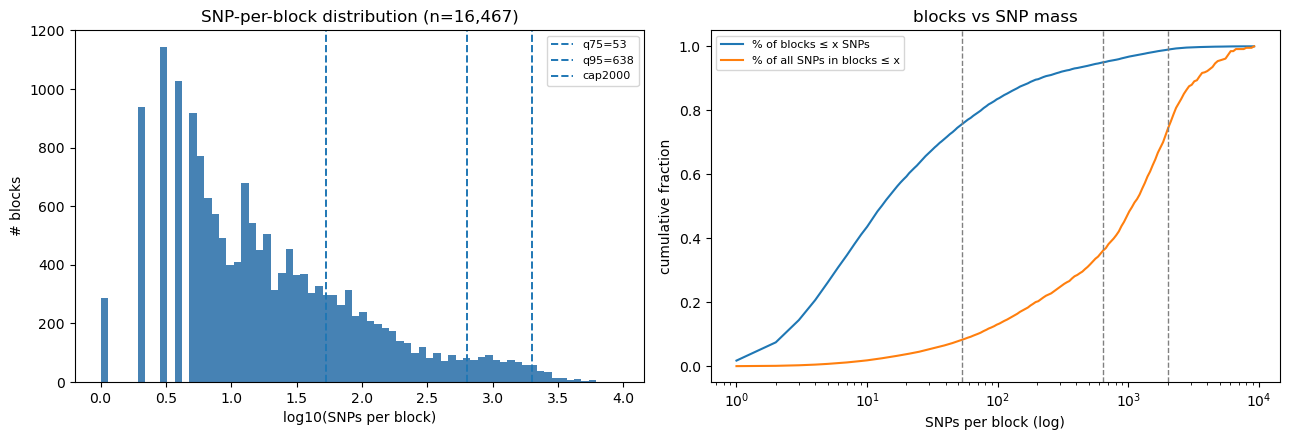

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(np.log10(n), bins=70, color="steelblue")
for c, lab in [(53, "q75=53"), (638, "q95=638"), (2000, "cap2000")]:
    ax[0].axvline(np.log10(c), ls="--", lw=1.4, label=lab)
ax[0].set(xlabel="log10(SNPs per block)", ylabel="# blocks",
          title=f"SNP-per-block distribution (n={len(n):,})"); ax[0].legend(fontsize=8)

xs = np.unique(np.round(np.logspace(0, np.log10(n.max()), 200)).astype(int))
ax[1].plot(xs, [(n <= x).mean() for x in xs], label="% of blocks ≤ x SNPs")
ax[1].plot(xs, [n[n <= x].sum()/n.sum() for x in xs], label="% of all SNPs in blocks ≤ x")
for c in (53, 638, 2000): ax[1].axvline(c, ls="--", lw=1, color="grey")
ax[1].set(xscale="log", xlabel="SNPs per block (log)", ylabel="cumulative fraction",
          title="blocks vs SNP mass"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. The polynomial fit — SD of window-Z vs SNPs/block (the failure)
Grey = empirical rolling-bin SD of Z (the data the correction fits). Curves = deg-2
(canonical Booker) and deg-7 (phase-1) fit on the rolling support, **evaluated over
the full SNP range**. Watch deg-2 turn **negative** past the support (→ NaN), and
deg-7 wiggle then explode. **Right panel:** the cap bounds everything to ≤2000, so
no extrapolation → no NaN, for any degree.

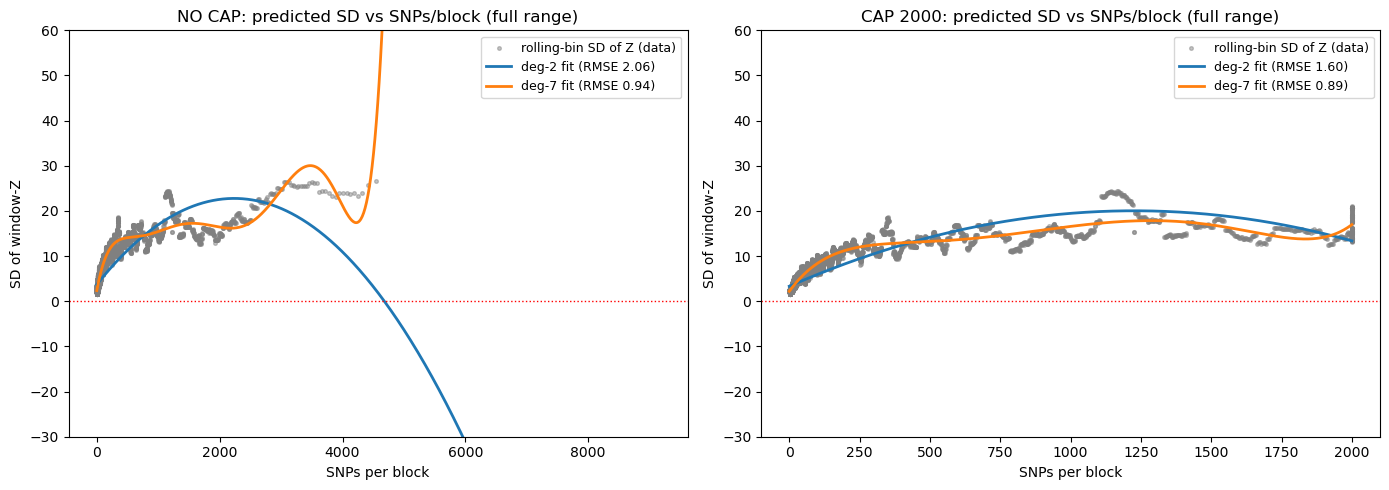

deg-2 with no cap dips below 0 in the tail -> norm.cdf returns NaN.
Capping removes the extrapolation; SD stays positive for any degree.


In [3]:
def rolling_support(rw, roller=50, minE=40):
    s = rw[~rw.Z.isnull()].sort_values("SNPs")
    var = s.Z.rolling(roller, min_periods=minE).var(); m = ~var.isnull()
    return (s.SNPs.rolling(roller, min_periods=minE).mean()[m].to_numpy(),
            np.sqrt(var[m]).to_numpy())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, (rw, lab, xmax) in zip(ax, [(base, "NO CAP", n.max()), (cap2k, "CAP 2000", 2000)]):
    x, sd = rolling_support(rw)
    a.scatter(x, sd, s=7, color="grey", alpha=.45, label="rolling-bin SD of Z (data)")
    g = np.linspace(0, xmax, 800)
    for deg, col in [(2, "C0"), (7, "C1")]:
        p = np.poly1d(np.polyfit(x, sd, deg))
        rmse = np.sqrt(np.mean((p(x) - sd)**2))
        a.plot(g, p(g), col, lw=2, label=f"deg-{deg} fit (RMSE {rmse:.2f})")
    a.axhline(0, color="red", ls=":", lw=1)
    a.set(xlabel="SNPs per block", ylabel="SD of window-Z",
          title=f"{lab}: predicted SD vs SNPs/block (full range)",
          ylim=(-30, 60)); a.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("deg-2 with no cap dips below 0 in the tail -> norm.cdf returns NaN.")
print("Capping removes the extrapolation; SD stays positive for any degree.")

## 3. What each cap actually touches
The cap **downsamples** SNPs inside oversized blocks (cap SNPs/draw × 100 resamples,
averaged). **No block is deleted** — every block still gets a WZA score.

In [4]:
rows = []
for c in (2000, int(n.quantile(.95)), int(n.quantile(.75))):
    above = n[n > c]
    rows.append(dict(cap=c, blocks_downsampled=len(above),
                     pct_blocks=round(len(above)/len(n)*100, 1),
                     SNPs_in_those_blocks=int(above.sum()),
                     pct_of_all_SNPs=round(above.sum()/n.sum()*100, 1)))
print(pd.DataFrame(rows).to_string(index=False))
print("\nNote: cap2000 touches ~1% of blocks but they hold ~26% of all SNPs — a few "
      "giant blocks dominate the SNP mass.")

 cap  blocks_downsampled  pct_blocks  SNPs_in_those_blocks  pct_of_all_SNPs
2000                 172         1.0                517742             26.0
 638                 824         5.0               1271398             63.9
  51                4095        24.9               1829728             92.0

Note: cap2000 touches ~1% of blocks but they hold ~26% of all SNPs — a few giant blocks dominate the SNP mass.


## 4. CAM5 adjudicated — polynomial-free
CAM5 block `2_1265` (13 SNPs, raw Z = 17.75 ≈ 18σ, a real coherent signal). Instead
of trusting either polynomial, estimate the null `(mean, SD)` of Z **directly from
blocks with a similar SNP count** and read off CAM5's p. This is the ground truth
the polynomial is supposed to approximate.

In [5]:
cam = base[base.block == "2_1265"].iloc[0]
print(f"CAM5 (2_1265): {int(cam.SNPs_raw)} SNPs, raw Z = {cam.Z:.3f}\n")
print("Polynomial-free local empirical null near 13 SNPs:")
for lo, hi in [(11, 15), (10, 16), (8, 20), (5, 25)]:
    nb_ = base[(base.SNPs_raw >= lo) & (base.SNPs_raw <= hi)]
    m, s = nb_.Z.mean(), nb_.Z.std()
    print(f"  {lo:2d}-{hi:2d} SNPs (n={len(nb_):4d}): mean={m:.3f} SD={s:.3f}"
          f"  ->  CAM5 p = {1-norm.cdf(cam.Z, m, s):.2e}")
print("\nWhat each polynomial said at 13 SNPs:")
for tag, deg, cap in [("deg2_nocap", 2, None), ("deg7_nocap", 7, None), ("deg2_cap2000", 2, 2000)]:
    rw = base if cap is None else cap2k
    mp, sp, _ = wc.fit_correction(rw, deg=deg)
    print(f"  {tag:13}: mean̂={mp(13):.2f} sd̂={sp(13):.2f}  ->  p = {1-norm.cdf(cam.Z, mp(13), sp(13)):.2e}")
print("\nTRUTH (local empirical) ~ 1.6e-4.  deg-2 too conservative (1.5e-3); "
      "deg-7 too liberal (5.7e-5) but closer.  Phase-1's published p~3e-8 is deg-7 tail over-fit.")

CAM5 (2_1265): 13 SNPs, raw Z = 17.754

Polynomial-free local empirical null near 13 SNPs:
  11-15 SNPs (n=1634): mean=5.454 SD=3.408  ->  CAM5 p = 1.54e-04
  10-16 SNPs (n=2277): mean=5.426 SD=3.430  ->  CAM5 p = 1.62e-04
   8-20 SNPs (n=4053): mean=5.355 SD=3.471  ->  CAM5 p = 1.77e-04
   5-25 SNPs (n=7056): mean=5.012 SD=3.501  ->  CAM5 p = 1.37e-04

What each polynomial said at 13 SNPs:
  deg2_nocap   : mean̂=6.09 sd̂=3.93  ->  p = 1.51e-03
  deg7_nocap   : mean̂=5.08 sd̂=3.29  ->  p = 5.73e-05
  deg2_cap2000 : mean̂=5.68 sd̂=3.67  ->  p = 5.09e-04

TRUTH (local empirical) ~ 1.6e-4.  deg-2 too conservative (1.5e-3); deg-7 too liberal (5.7e-5) but closer.  Phase-1's published p~3e-8 is deg-7 tail over-fit.


## 5. Takeaways
1. **The cap is the load-bearing fix.** The NaN is an *extrapolation* artifact (deg-2
   predicting past the ~4,500-SNP rolling support out to the 9,158-SNP blocks). Any
   cap removes the extrapolation → no NaN, regardless of degree.
2. **deg-7 genuinely fits the curve better** (lower RMSE; closer at CAM5) — the author
   was right that a quadratic is too rigid here. Its danger is *tail extrapolation*,
   which the cap eliminates. So the author's *(cap=2000 + deg-7)* is internally
   consistent; deg-7 alone (phase-1, no cap) is the fragile part.
3. **deg-2 is the canonical default and more stable** (Bonferroni count swings
   25→6 between degrees; deg-2 less wiggly), but **slightly conservative** at low SNP
   counts. With the cap, deg-2 vs deg-7 is a judgement call — best resolved by the
   **local empirical null** (§4), which both polynomials only approximate.
4. WZA does **not** over-weight low-SNP windows — small windows are *under*-powered;
   deg-7 is what lifts CAM5-sized windows. CAM5 is a real top-~0.1% block (p≈1.6e-4),
   just over-stated by the uncapped deg-7.